In [2]:
import pandas as pd

df_delivery = pd.read_csv('../data/delivery_delay_review_summary.csv')

In [3]:
print(df_delivery.shape)
print(df_delivery.head())
print(df_delivery.dtypes)
print(df_delivery.isna().sum())

(95830, 3)
                           order_id  review_score  delivery_delay_days
0  0005a1a1728c9d785b8e2b08b904576c           1.0                    0
1  000aed2e25dbad2f9ddb70584c5a2ded           1.0                   -4
2  00169e31ef4b29deaae414f9a5e95929           1.0                  -15
3  0017afd5076e074a48f1f1a4c7bac9c5           1.0                    4
4  001d8f0e34a38c37f7dba2a37d4eba8b           1.0                    2
order_id                   str
review_score           float64
delivery_delay_days      int64
dtype: object
order_id               0
review_score           0
delivery_delay_days    0
dtype: int64


In [5]:
df_delivery.groupby("review_score")[["delivery_delay_days"]].describe()

delivery_delay_days                                           \
                           count       mean        std    min   25%   50%   
review_score                                                                
1.0                       9316.0  -4.026191  16.064683  -69.0 -14.0  -7.0   
2.0                       2924.0  -8.628249  12.649204  -56.0 -15.0 -10.0   
3.0                       7947.0 -10.767963  10.384977 -135.0 -16.0 -11.0   
4.0                      18892.0 -12.381431   9.064218  -75.0 -17.0 -12.0   
5.0                      56751.0 -13.383112   8.153549 -147.0 -18.0 -13.0   

                          
              75%    max  
review_score              
1.0           6.0  175.0  
2.0          -3.0  188.0  
3.0          -6.0  162.0  
4.0          -7.0  161.0  
5.0          -8.0  155.0

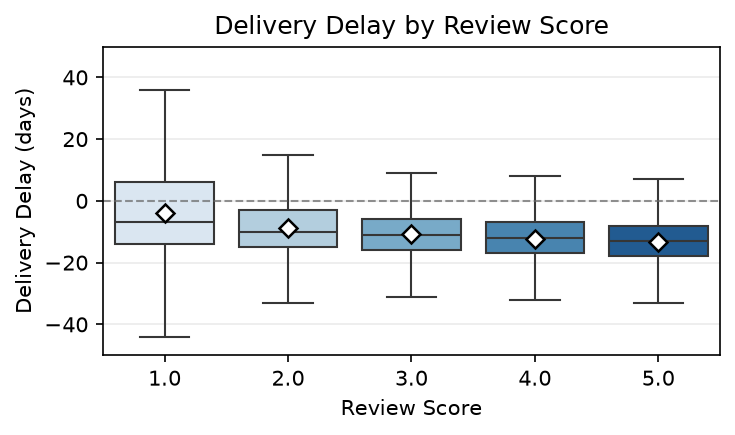

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

review_order = sorted(df_delivery["review_score"].unique())
review_palette = dict(
    zip(review_order, sns.color_palette("Blues", n_colors=len(review_order)))
)

plt.figure(figsize=(5, 3))
sns.boxplot(
    data=df_delivery,
    x="review_score",
    y="delivery_delay_days",
    order=review_order,
    hue="review_score",
    hue_order=review_order,
    palette=review_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markeredgewidth": 1.2,
        "markersize": 6,
    },
)
plt.ylim(-50, 50)
plt.axhline(0, color="#666666", linewidth=1, linestyle="--", alpha=0.7)
plt.title("Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (days)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import kruskal

groups_delivery_delay = [
    group["delivery_delay_days"].values
    for _, group in df_delivery.groupby("review_score")
]

stat_delivery_delay, p_delivery_delay = kruskal(*groups_delivery_delay)

print("== Kruskal-Wallis Test ==")
print()
print("[Delivery Delay Days]")
print(f"H-statistic: {stat_delivery_delay:.4f}")
print(f"p-value: {p_delivery_delay:.3e}")

== Kruskal-Wallis Test ==

[Delivery Delay Days]
H-statistic: 3890.1397
p-value: 0.000e+00


In [7]:
import scikit_posthocs as sp

dunn_delivery = sp.posthoc_dunn(
    df_delivery,
    val_col="delivery_delay_days",
    group_col="review_score",
    p_adjust="bonferroni"
)

dunn_delivery

,1.0,2.0,3.0,4.0,5.0
1.0,1.000000e+00,8.827959e-34,2.637844e-148,0.000000e+00,0.000000e+00
2.0,8.827959e-34,1.000000e+00,2.679655e-09,8.721660e-45,3.226815e-96
3.0,2.637844e-148,2.679655e-09,1.000000e+00,1.241987e-26,1.246768e-103
4.0,0.000000e+00,8.721660e-45,1.241987e-26,1.000000e+00,2.455354e-41
5.0,0.000000e+00,3.226815e-96,1.246768e-103,2.455354e-41,1.000000e+00


In [3]:
median_summary_delivery = (
    df_delivery
    .groupby("review_score")[["delivery_delay_days"]]
    .median()
)

median_summary_delivery["delivery_delay_days_diff_vs_5"] = (
    median_summary_delivery["delivery_delay_days"]
    - median_summary_delivery.loc[5, "delivery_delay_days"]
)

median_summary_delivery

,delivery_delay_days,delivery_delay_days_diff_vs_5
review_score,,
1.0,-7.0,6.0
2.0,-10.0,3.0
3.0,-11.0,2.0
4.0,-12.0,1.0
5.0,-13.0,0.0


In [8]:
mean_sum_delivery_delay_days = (
    df_delivery
    .groupby("review_score")[["delivery_delay_days"]]
    .mean()
)

mean_sum_delivery_delay_days["delivery_delay_days_diff_vs_5"] =(
    mean_sum_delivery_delay_days["delivery_delay_days"]
    - mean_sum_delivery_delay_days.loc[5, "delivery_delay_days"]
)

mean_sum_delivery_delay_days

,delivery_delay_days,delivery_delay_days_diff_vs_5
review_score,,
1.0,-4.026191,9.356921
2.0,-8.628249,4.754863
3.0,-10.767963,2.615149
4.0,-12.381431,1.001681
5.0,-13.383112,0.000000


In [ ]:

N = len(df_delivery)
K = df_delivery["review_score"].nunique()

epsilon_delivery = (stat_delivery_delay - K + 1) / (N - K)

print(f"Delivery Delay Days  ε²: {epsilon_delivery:.6f}")



Delivery Delay Days  ε²: 0.040555


In [9]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import mannwhitneyu

results = []

review_scores = sorted(df_delivery["review_score"].dropna().unique())

for score_1, score_2 in combinations(review_scores, 2):
    x = df_delivery.loc[
        df_delivery["review_score"] == score_1,
        "delivery_delay_days"
    ].dropna().to_numpy()

    y = df_delivery.loc[
        df_delivery["review_score"] == score_2,
        "delivery_delay_days"
    ].dropna().to_numpy()

    # Mann–WhitneyのU統計量からCliff's deltaを算出
    u_stat = mannwhitneyu(
        x,
        y,
        alternative="two-sided",
        method="asymptotic"
    ).statistic

    cliffs_delta = (2 * u_stat) / (len(x) * len(y)) - 1

    results.append({
        "review_score_1": score_1,
        "review_score_2": score_2,
        "n_1": len(x),
        "n_2": len(y),
        "median_1": np.median(x),
        "median_2": np.median(y),
        "median_diff_1_minus_2": np.median(x) - np.median(y),
        "dunn_p_adjusted": dunn_delivery.loc[score_1, score_2],
        "cliffs_delta": cliffs_delta,
        "abs_cliffs_delta": abs(cliffs_delta)
    })

effect_size_delivery = pd.DataFrame(results)

effect_size_delivery

,review_score_1,review_score_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,dunn_p_adjusted,cliffs_delta,abs_cliffs_delta
0,1.0,2.0,9316,2924,-7.0,-10.0,3.0,8.827959e-34,0.167967,0.167967
1,1.0,3.0,9316,7947,-7.0,-11.0,4.0,2.637844e-148,0.254124,0.254124
2,1.0,4.0,9316,18892,-7.0,-12.0,5.0,0.000000e+00,0.324942,0.324942
3,1.0,5.0,9316,56751,-7.0,-13.0,6.0,0.000000e+00,0.371017,0.371017
4,2.0,3.0,2924,7947,-10.0,-11.0,1.0,2.679655e-09,0.087919,0.087919
5,2.0,4.0,2924,18892,-10.0,-12.0,2.0,8.721660e-45,0.170114,0.170114
6,2.0,5.0,2924,56751,-10.0,-13.0,3.0,3.226815e-96,0.228057,0.228057
7,3.0,4.0,7947,18892,-11.0,-12.0,1.0,1.241987e-26,0.088203,0.088203
8,3.0,5.0,7947,56751,-11.0,-13.0,2.0,1.246768e-103,0.153240,0.153240
9,4.0,5.0,18892,56751,-12.0,-13.0,1.0,2.455354e-41,0.068951,0.068951


In [10]:
def interpret_cliffs_delta(delta):
    delta = abs(delta)

    if delta < 0.147:
        return "negligible"
    elif delta < 0.330:
        return "small"
    elif delta < 0.474:
        return "medium"
    else:
        return "large"


effect_size_delivery["effect_size"] = (
    effect_size_delivery["cliffs_delta"]
    .apply(interpret_cliffs_delta)
)

effect_size_delivery.sort_values(
    "abs_cliffs_delta",
    ascending=False
)

,review_score_1,review_score_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,dunn_p_adjusted,cliffs_delta,abs_cliffs_delta,effect_size
3,1.0,5.0,9316,56751,-7.0,-13.0,6.0,0.000000e+00,0.371017,0.371017,medium
2,1.0,4.0,9316,18892,-7.0,-12.0,5.0,0.000000e+00,0.324942,0.324942,small
1,1.0,3.0,9316,7947,-7.0,-11.0,4.0,2.637844e-148,0.254124,0.254124,small
6,2.0,5.0,2924,56751,-10.0,-13.0,3.0,3.226815e-96,0.228057,0.228057,small
5,2.0,4.0,2924,18892,-10.0,-12.0,2.0,8.721660e-45,0.170114,0.170114,small
0,1.0,2.0,9316,2924,-7.0,-10.0,3.0,8.827959e-34,0.167967,0.167967,small
8,3.0,5.0,7947,56751,-11.0,-13.0,2.0,1.246768e-103,0.153240,0.153240,small
7,3.0,4.0,7947,18892,-11.0,-12.0,1.0,1.241987e-26,0.088203,0.088203,negligible
4,2.0,3.0,2924,7947,-10.0,-11.0,1.0,2.679655e-09,0.087919,0.087919,negligible
9,4.0,5.0,18892,56751,-12.0,-13.0,1.0,2.455354e-41,0.068951,0.068951,negligible
